# ***Análisis y Predicción de la Deserción de Empleados en IBM***

## **Notebook de análisis para el video - Clase N°6**

**Alumno:** Ariel Tuñon  
**Institución:** Politécnico Superior Malvinas Argentinas  
**Asignatura:** Aprendizaje Automático  
**Año:** 2026

---


## **Introducción**

El dataset IBM HR Analytics – Employee Attrition permite analizar y predecir la rotación de empleados a partir de diferentes características personales, laborales y organizacionales.

### **Propósito**

Desarrollar un modelo de aprendizaje automático capaz de predecir si un empleado abandonará la empresa, con el objetivo de identificar anticipadamente a aquellos que presentan un mayor riesgo de renuncia y facilitar la implementación de estrategias de retención.

### **Variable objetivo**

**La variable objetivo es Attrition (abandono laboral):**

**Yes** → el empleado abandonó la empresa.

**No** → el empleado permaneció en la empresa.

Por lo tanto, se trata de un problema de aprendizaje supervisado de clasificación binaria, en el que el modelo aprende a partir de las características de los empleados para predecir una de las dos categorías posibles: Yes o No.
---
El dataset tiene 1.470 registros y 35 variables, incluyendo variables numéricas como edad, ingreso mensual y años en la empresa, y categóricas como puesto, estado civil y viajes de trabajo.

### **Predictoras posibles:**

•	Age → numérica

•	MonthlyIncome → numérica

•	YearsAtCompany → numérica

•	JobSatisfaction → numérica/ordinal

•	DistanceFromHome → numérica

•	JobRole → categórica

•	MaritalStatus → categórica

•	BusinessTravel → categórica

•	Department → categórica

•	Gender → categórica


---

### Herramientas utilizadas

**Python · Pandas · NumPy · Matplotlib · Seaborn · Scikit-learn**

**Fuente:** https://www.kaggle.com/code/vincentlugat/ibm-attrition-analysis-and-prediction

**Dataset:** IBM.scv

https://github.com/arieltunon74/Aprendizaje_Automatico_2026/blob/main/Clase6/Datos/IBM.csv

---


### **CARGA DEL DATASET IBM.SCV**

In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/arieltunon74/Aprendizaje_Automatico_2026/main/Clase6/Datos/IBM.csv"
df = pd.read_csv(url)
df.head()

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
1,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
2,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
3,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
4,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2


# **ANÁLISIS EXPLORATORIO DE DATOS (EDA)**

In [ ]:
# Exploración inicial del dataset

print("========== INFORMACIÓN DEL DATASET ==========")
print(f"\nCantidad de registros: {df.shape[0]:,}")
print(f"Cantidad de variables: {df.shape[1]}")
print("\n========== NOMBRES DE LAS VARIABLES ==========")
for i, columna in enumerate(df.columns, start=1):
    print(f"{i}. {columna}")

print("\n========== TIPOS DE DATOS ==========")
print(df.dtypes)

print("\n========== REGISTROS DUPLICADOS ==========")
# Duplicados
duplicados = df.duplicated().sum()
print("\n🔹 REGISTROS DUPLICADOS")
print(f"   {duplicados:,} registros duplicados")
print("\n" * 2)


# Conteo total de nulos por columna
nulos_por_columna = df.isnull().sum()

# Porcentaje de nulos por columna
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

# Crear un DataFrame resumen con las columnas que tienen valores nulos
resumen_nulos = pd.DataFrame({
    'Valores Nulos': nulos_por_columna,
    'Porcentaje (%)': porcentaje_nulos.round(2)
})

# Mostrar solo las columnas que contengan al menos 1 valor nulo
columnas_con_nulos = resumen_nulos[resumen_nulos['Valores Nulos'] > 0]

print(f"Total de filas en el dataset: {len(df)}\n")

if columnas_con_nulos.empty:
    print("✅ ¡No hay valores nulos en ninguna columna del dataset!")
else:
    print("⚠️ Columnas con valores nulos encontrados:")
    display(columnas_con_nulos)

========== INFORMACIÓN DEL DATASET ==========

Cantidad de registros: 1,470
Cantidad de variables: 13

========== NOMBRES DE LAS VARIABLES ==========
1. Age
2. Attrition
3. Department
4. DistanceFromHome
5. Education
6. EducationField
7. EnvironmentSatisfaction
8. JobSatisfaction
9. MaritalStatus
10. MonthlyIncome
11. NumCompaniesWorked
12. WorkLifeBalance
13. YearsAtCompany

========== TIPOS DE DATOS ==========
Age                         int64
Attrition                  object
Department                 object
DistanceFromHome            int64
Education                   int64
EducationField             object
EnvironmentSatisfaction     int64
JobSatisfaction             int64
MaritalStatus              object
MonthlyIncome               int64
NumCompaniesWorked          int64
WorkLifeBalance             int64
YearsAtCompany              int64
dtype: object

========== REGISTROS DUPLICADOS ==========

🔹 REGISTROS DUPLICADOS
   0 registros duplicados



Total de filas en el dataset: 1

### **RESUMEN ESTADISTICO**

In [ ]:

print("\n========== RESUMEN ESTADÍSTICO ==========")
display(df.describe(include="all").T)


========== RESUMEN ESTADÍSTICO ==========


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EnvironmentSatisfaction,1470.0,NaN,NaN,NaN,2.721769,1.093082,1.0,2.0,3.0,4.0,4.0
JobSatisfaction,1470.0,NaN,NaN,NaN,2.728571,1.102846,1.0,2.0,3.0,4.0,4.0
MaritalStatus,1470,3,Married,673,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MonthlyIncome,1470.0,NaN,NaN,NaN,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0


### **ANALISIS DE LA VARIABLE OBJETIVO - Attrition (abandono laboral)**

/tmp/ipykernel_485/2460427878.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


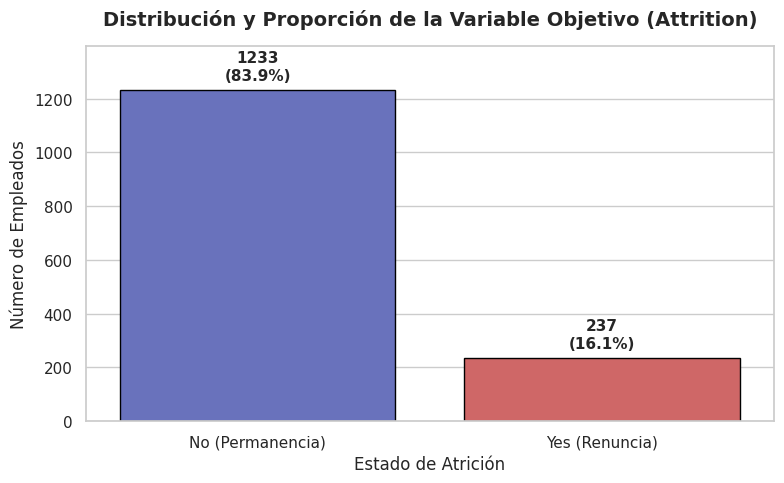

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Forzamos el orden explícito: primero 'No', luego 'Yes'
ax = sns.countplot(
    data=df,
    x="Attrition",
    order=["No", "Yes"],
    palette=["#5B67CA", "#E05656"],
    edgecolor="black",
)

total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f"{(height / total) * 100:.1f}%"
    count = f"{int(height)}"

    ax.annotate(
        f"{count}\n({percentage})",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        xytext=(0, 5),
        textcoords="offset points",
    )

plt.title(
    "Distribución y Proporción de la Variable Objetivo (Attrition)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Estado de Atrición", fontsize=12)
plt.ylabel("Número de Empleados", fontsize=12)

# Asignación correcta de etiquetas manteniendo el orden ["No", "Yes"]
plt.xticks(ticks=[0, 1], labels=["No (Permanencia)", "Yes (Renuncia)"])
plt.ylim(0, total * 0.95)

plt.tight_layout()
plt.show()

### La variable objetivo se observa fuertemente desbalanceada

Magnitud del Desbalance: Refleja la proporción real entre la clase mayoritaria (No Attrition, aprox. 84%)

y la minoritaria (Attrition, aprox. 16%)

### **TRATAMIENTO DE VALORES ATIPICOS (OUTLIERS) - Verificación**

In [ ]:
# Seleccionar solo columnas numéricas
num_cols = df.select_dtypes(include=[np.number]).columns

# Conteo de outliers usando IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)]
    if len(outliers) > 0:
        print(f"Columna '{col}': {len(outliers)} outliers ({round(len(outliers)/len(df)*100, 2)}%)")

Columna 'MonthlyIncome': 114 outliers (7.76%)
Columna 'NumCompaniesWorked': 52 outliers (3.54%)
Columna 'YearsAtCompany': 104 outliers (7.07%)


## TRATAMIENTO DE VALORES ATÍPICOS MEDIANTE WINSORIZACIÓN (CAPPING) Y TRANSFORMACIÓN LOGARÍTMICA

In [ ]:

# 1. Transformación logarítmica para ingreso
df['MonthlyIncome_log'] = np.log1p(df['MonthlyIncome'])

# 2. Capping para YearsAtCompany y NumCompaniesWorked
for col in ['YearsAtCompany', 'NumCompaniesWorked']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_sup = Q3 + 1.5 * IQR

    df[f'{col}_capped'] = np.where(df[col] > lim_sup, lim_sup, df[col])

print("Tratamiento de outliers completado exitosamente.")

Tratamiento de outliers completado exitosamente.


### **VERIFICACIÓN DEL TRATAMIENTO DE OUTLIERS REALIZADO**

--- RESUMEN DE VERIFICACIÓN DE OUTLIERS ---


,Columna Original,Outliers Originales,Columna Tratada,Outliers Restantes
0,MonthlyIncome,114,MonthlyIncome_log,0
1,YearsAtCompany,104,YearsAtCompany_capped,0
2,NumCompaniesWorked,52,NumCompaniesWorked_capped,0



--- COMPARACIÓN DE VALORES MÁXIMOS ---
MonthlyIncome (Máx Original): 19,999.00  -->  MonthlyIncome_log (Máx Tratado): 9.90
YearsAtCompany (Máx Original): 40  -->  YearsAtCompany_capped (Máx Tratado): 18.0
NumCompaniesWorked (Máx Original): 9  -->  NumCompaniesWorked_capped (Máx Tratado): 8.5


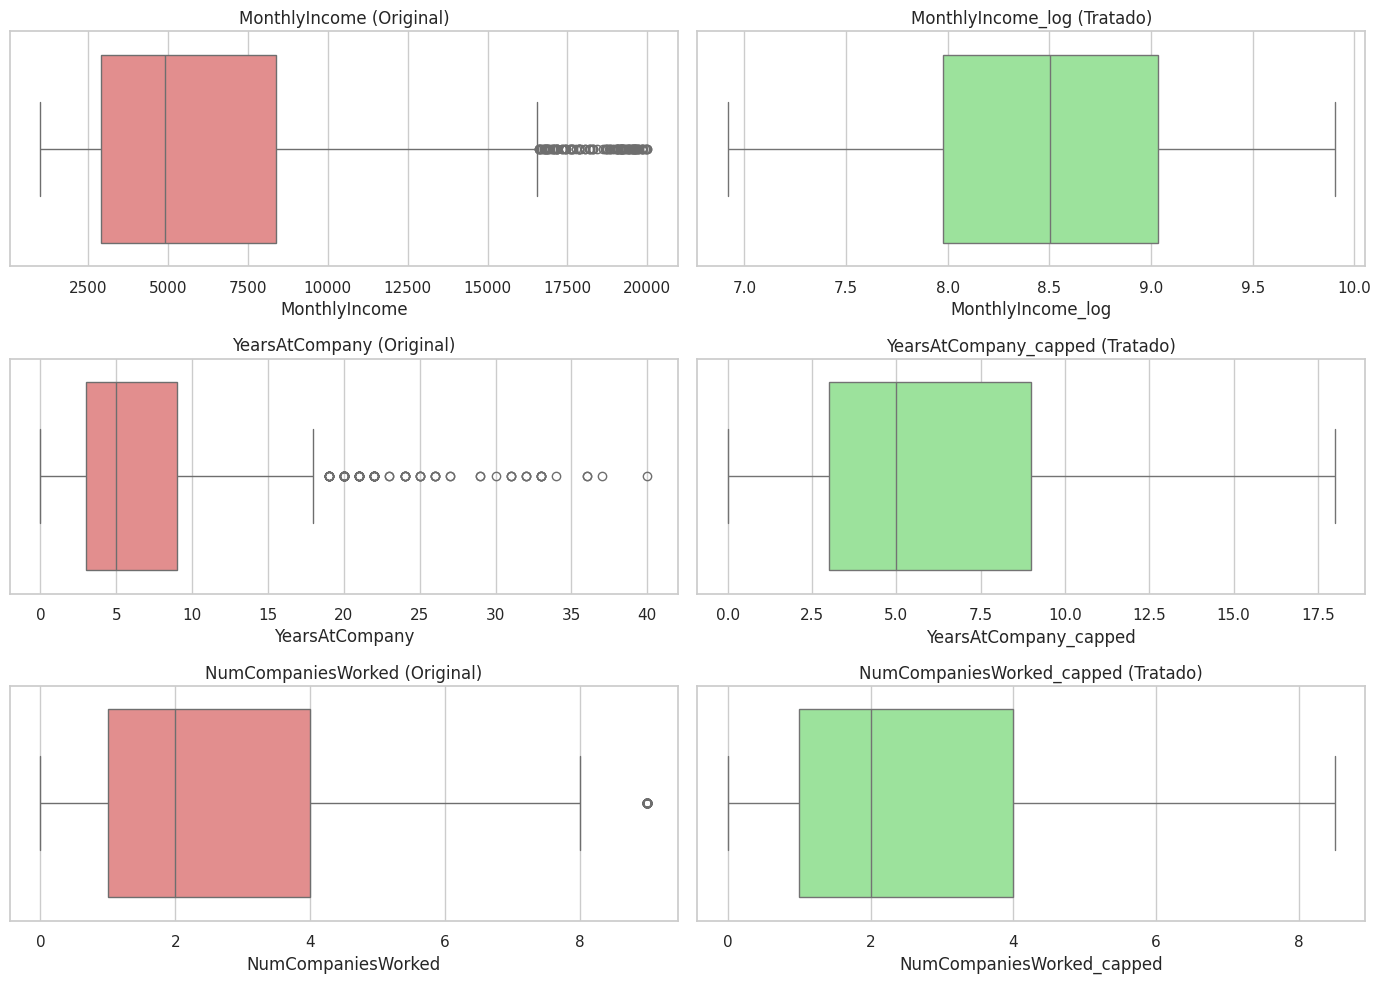

In [ ]:

# -------------------------------------------------------------
# 1. VERIFICACIÓN ESTADÍSTICA (Conteo de Outliers antes vs después)
# -------------------------------------------------------------
def contar_outliers(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    return ((serie < lim_inf) | (serie > lim_sup)).sum()

# Comparación en 'MonthlyIncome'
outliers_original_income = contar_outliers(df['MonthlyIncome'])
outliers_tratado_income = contar_outliers(df['MonthlyIncome_log'])

# Comparación en 'YearsAtCompany'
outliers_original_years = contar_outliers(df['YearsAtCompany'])
outliers_tratado_years = contar_outliers(df['YearsAtCompany_capped'])

# Comparación en 'NumCompaniesWorked'
outliers_original_num = contar_outliers(df['NumCompaniesWorked'])
outliers_tratado_num = contar_outliers(df['NumCompaniesWorked_capped'])

resumen = pd.DataFrame({
    'Columna Original': ['MonthlyIncome', 'YearsAtCompany', 'NumCompaniesWorked'],
    'Outliers Originales': [outliers_original_income, outliers_original_years, outliers_original_num],
    'Columna Tratada': ['MonthlyIncome_log', 'YearsAtCompany_capped', 'NumCompaniesWorked_capped'],
    'Outliers Restantes': [outliers_tratado_income, outliers_tratado_years, outliers_tratado_num]
})

print("--- RESUMEN DE VERIFICACIÓN DE OUTLIERS ---")
display(resumen)

# -------------------------------------------------------------
# 2. VERIFICACIÓN DE VALORES MÁXIMOS Y DISTRIBUCIÓN
# -------------------------------------------------------------
print("\n--- COMPARACIÓN DE VALORES MÁXIMOS ---")
print(f"MonthlyIncome (Máx Original): {df['MonthlyIncome'].max():,.2f}  -->  MonthlyIncome_log (Máx Tratado): {df['MonthlyIncome_log'].max():.2f}")
print(f"YearsAtCompany (Máx Original): {df['YearsAtCompany'].max()}  -->  YearsAtCompany_capped (Máx Tratado): {df['YearsAtCompany_capped'].max()}")
print(f"NumCompaniesWorked (Máx Original): {df['NumCompaniesWorked'].max()}  -->  NumCompaniesWorked_capped (Máx Tratado): {df['NumCompaniesWorked_capped'].max()}")

# -------------------------------------------------------------
# 3. VERIFICACIÓN VISUAL (Boxplots Comparativos)
# -------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# MonthlyIncome
sns.boxplot(x=df['MonthlyIncome'], ax=axes[0, 0], color='lightcoral')
axes[0, 0].set_title('MonthlyIncome (Original)')

sns.boxplot(x=df['MonthlyIncome_log'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('MonthlyIncome_log (Tratado)')

# YearsAtCompany
sns.boxplot(x=df['YearsAtCompany'], ax=axes[1, 0], color='lightcoral')
axes[1, 0].set_title('YearsAtCompany (Original)')

sns.boxplot(x=df['YearsAtCompany_capped'], ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('YearsAtCompany_capped (Tratado)')

# NumCompaniesWorked
sns.boxplot(x=df['NumCompaniesWorked'], ax=axes[2, 0], color='lightcoral')
axes[2, 0].set_title('NumCompaniesWorked (Original)')

sns.boxplot(x=df['NumCompaniesWorked_capped'], ax=axes[2, 1], color='lightgreen')
axes[2, 1].set_title('NumCompaniesWorked_capped (Tratado)')

plt.tight_layout()
plt.show()

## **SEPARACIÓN DE X e Y (MATRIZ DE CARACTERÍSTICAS Y VARIABLE OBJETIVO)**
## **MÉTODOS DE CONVERSION: StandardScaler Y OneHotEncoder.**
## **DIVISIÓN DEL DATASET EN ENTRENADOR Y PRUEBA (TRAIN / TEST SPLIT) - 80 / 20**


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Eliminar columnas sin varianza o no informativas
cols_inutiles = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = df.drop(columns=[c for c in cols_inutiles if c in df.columns])

# ==========================================
# 1. SEPARACIÓN X / y
# ==========================================
if df['Attrition'].dtype == 'object':
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['Attrition'])
y = df['Attrition']

# ==========================================
# 2. NUMÉRICAS / CATEGÓRICAS + PREPROCESAMIENTO
# ==========================================
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# Aplicar transformación a X
X_processed = preprocessor.fit_transform(X)

# ==========================================
# 3. TRAIN / TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## **IMPLEMENTACIÓN Y GRÁFICAS DEL MODELO NEAREST NEIGHBORS (K-NN)**

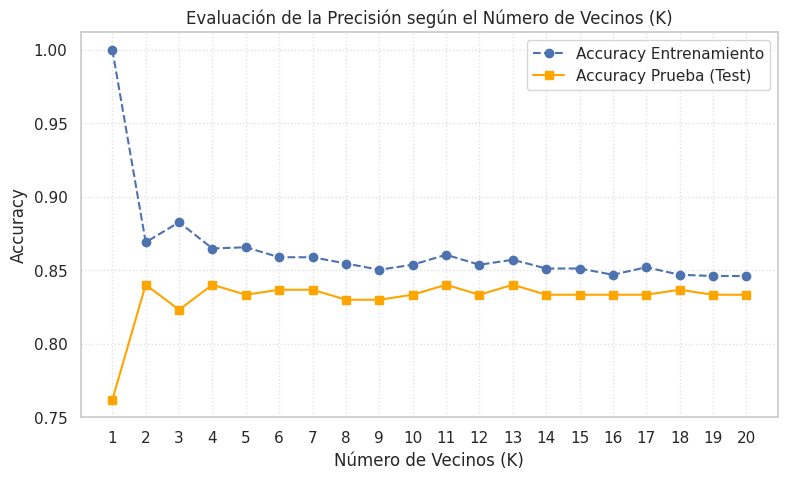

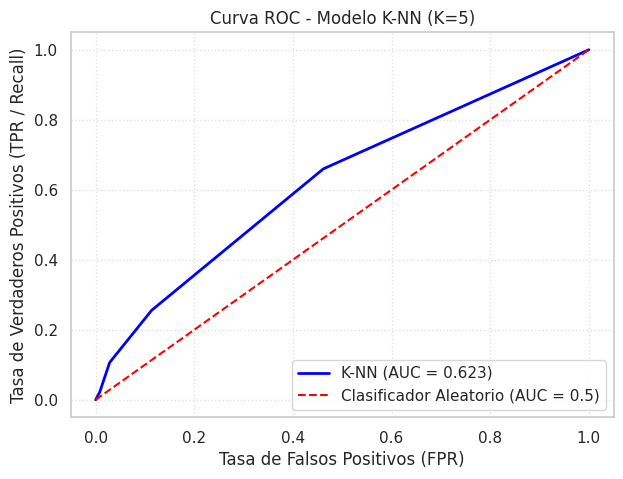

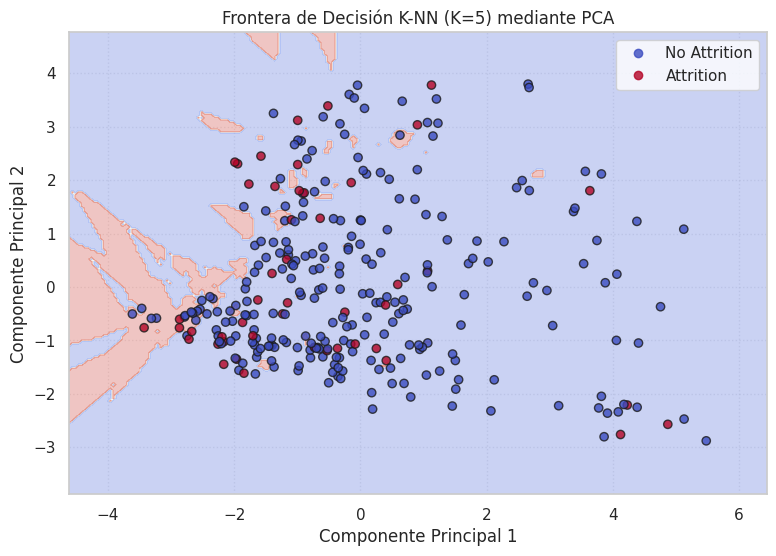

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay


# Eliminar columnas irrelevantes
cols_inutiles = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = df.drop(columns=[c for c in cols_inutiles if c in df.columns])

# Separación X e y
if df['Attrition'].dtype == 'object':
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['Attrition'])
y = df['Attrition']

# Preprocesamiento con ColumnTransformer
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.20, random_state=42, stratify=y
)

# ==========================================
# GRAFICO 1: OPTIMIZACIÓN DEL VALOR DE K
# ==========================================
k_values = range(1, 21)
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    train_accuracies.append(knn_temp.score(X_train, y_train))
    test_accuracies.append(knn_temp.score(X_test, y_test))

plt.figure(figsize=(9, 5))
plt.plot(k_values, train_accuracies, label='Accuracy Entrenamiento', marker='o', linestyle='--')
plt.plot(k_values, test_accuracies, label='Accuracy Prueba (Test)', marker='s', color='orange')
plt.title('Evaluación de la Precisión según el Número de Vecinos (K)')
plt.xlabel('Número de Vecinos (K)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
print("\n" * 2)

# ==========================================
# GRAFICO 2: CURVA ROC - AUC DE K-NN
# ==========================================
k_optimo = 5
knn = KNeighborsClassifier(n_neighbors=k_optimo)
knn.fit(X_train, y_train)

y_probs = knn.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'K-NN (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=1.5, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title(f'Curva ROC - Modelo K-NN (K={k_optimo})')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
print("\n" * 2)

# ==========================================
# GRAFICO 3: FRONTERA DE DECISIÓN (PCA 2D)
# ==========================================
# Reducción a 2 dimensiones con PCA para graficar la frontera en 2D
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

knn_pca = KNeighborsClassifier(n_neighbors=k_optimo)
knn_pca.fit(X_train_pca, y_train)

# Crear malla (malla espacial)
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', alpha=0.8)
plt.title(f'Frontera de Decisión K-NN (K={k_optimo}) mediante PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(handles=scatter.legend_elements()[0], labels=['No Attrition', 'Attrition'])
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()
print("\n" * 2)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# Eliminar columnas irrelevantes
cols_inutiles = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = df.drop(columns=[c for c in cols_inutiles if c in df.columns])

# Separación X e y
if df['Attrition'].dtype == 'object':
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['Attrition'])
y = df['Attrition']

# Preprocesamiento con ColumnTransformer
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.20, random_state=42, stratify=y
)

# =========================================================
#  AQUÍ SE AJUSTA EL VALOR DE K
# =========================================================
k_elegido = 5  # <-- Modifica este valor (se recomiendan impares como 5, 7 o 11)

knn = KNeighborsClassifier(n_neighbors=k_elegido)
knn.fit(X_train, y_train)

print(f"Modelo K-NN entrenado exitosamente con K = {k_elegido}")

Modelo K-NN entrenado exitosamente con K = 5


### **IMPLEMENTACIÓN Y GRÁFICAS DEL MODELO DE REGRESIÓN LOGISTICA**

/tmp/ipykernel_485/1391720953.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_coefs, x='Coeficiente', y='Caracteristica', palette='coolwarm')


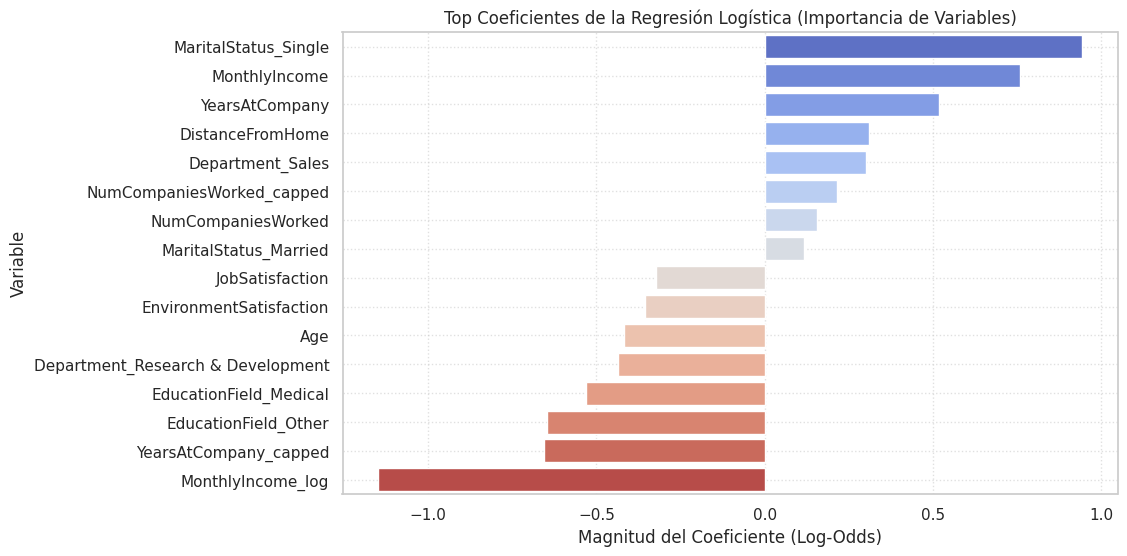

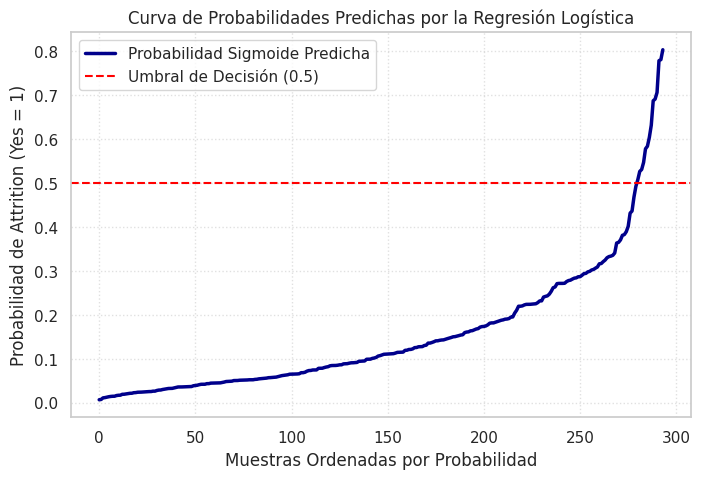

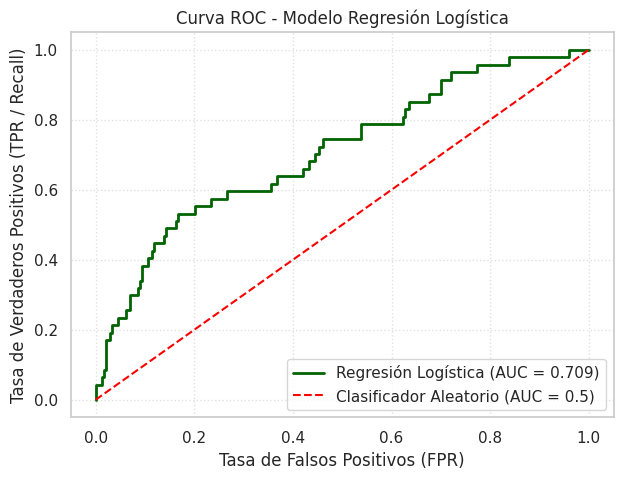

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Eliminar columnas redundantes
cols_inutiles = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = df.drop(columns=[c for c in cols_inutiles if c in df.columns])

# Separación X e y
if df['Attrition'].dtype == 'object':
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['Attrition'])
y = df['Attrition']

# Preprocesamiento con ColumnTransformer
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

# Guardar nombres de características procesadas
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_cols = cat_encoder.get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + encoded_cat_cols

# Split de Train y Test
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.20, random_state=42, stratify=y
)

# Entrenamiento de Regresión Logística
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# ==========================================
# GRAFICO 1: IMPORTANCIA DE CARACTERÍSTICAS (COEFICIENTES)
# ==========================================
coefs = pd.DataFrame({
    'Caracteristica': feature_names,
    'Coeficiente': model.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# Mostrar top 10 variables que más influyen positiva y negativamente
top_coefs = pd.concat([coefs.head(8), coefs.tail(8)])

plt.figure(figsize=(10, 6))
sns.barplot(data=top_coefs, x='Coeficiente', y='Caracteristica', palette='coolwarm')
plt.title('Top Coeficientes de la Regresión Logística (Importancia de Variables)')
plt.xlabel('Magnitud del Coeficiente (Log-Odds)')
plt.ylabel('Variable')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
print("\n" * 2)

# ==========================================
# GRAFICO 2: CURVA SIGMOIDE DE PROBABILIDAD PREDICHA
# ==========================================
# Proyección de las probabilidades predichas
y_probs = model.predict_proba(X_test)[:, 1]

# Ordenar las probabilidades para graficar la función logística
probs_ordenadas = np.sort(y_probs)

plt.figure(figsize=(8, 5))
plt.plot(probs_ordenadas, color='darkblue', lw=2.5, label='Probabilidad Sigmoide Predicha')
plt.axhline(0.5, color='red', linestyle='--', label='Umbral de Decisión (0.5)')
plt.title('Curva de Probabilidades Predichas por la Regresión Logística')
plt.xlabel('Muestras Ordenadas por Probabilidad')
plt.ylabel('Probabilidad de Attrition (Yes = 1)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
print("\n" * 2)

# ==========================================
# GRAFICO 3: CURVA ROC - AUC
# ==========================================
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'Regresión Logística (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=1.5, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curva ROC - Modelo Regresión Logística')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
print("\n" * 2)

=== RESULTADOS CON UMBRAL = 0.25 ===

Matriz de Confusión:
[[211  36]
 [ 24  23]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88       247
           1       0.39      0.49      0.43        47

    accuracy                           0.80       294
   macro avg       0.64      0.67      0.65       294
weighted avg       0.82      0.80      0.80       294



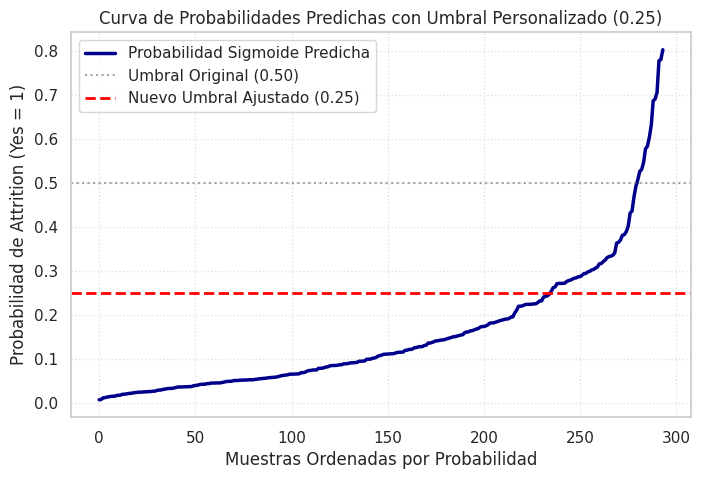

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. DEFINICIÓN Y APLICACIÓN DEL NUEVO UMBRAL
# ==========================================
# Obtenemos las probabilidades predichas de la clase positiva (Attrition = 1)
y_probs = model.predict_proba(X_test)[:, 1]

# Definimos el nuevo umbral (ejemplo: 0.25 para aumentar la sensibilidad/Recall)
UMBRAL = 0.25

# Generamos las predicciones binarias aplicando la condición
y_pred_ajustado = (y_probs >= UMBRAL).astype(int)

# ==========================================
# 2. EVALUACIÓN DE RESULTADOS
# ==========================================
print(f"=== RESULTADOS CON UMBRAL = {UMBRAL} ===")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_ajustado))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_ajustado))

# ==========================================
# 3. GRAFICO: SIGMOIDE CON EL NUEVO UMBRAL
# ==========================================
probs_ordenadas = np.sort(y_probs)

plt.figure(figsize=(8, 5))
plt.plot(
    probs_ordenadas,
    color='darkblue',
    lw=2.5,
    label='Probabilidad Sigmoide Predicha',
)
plt.axhline(
    0.5,
    color='gray',
    linestyle=':',
    alpha=0.7,
    label='Umbral Original (0.50)',
)
plt.axhline(
    UMBRAL,
    color='red',
    linestyle='--',
    lw=2,
    label=f'Nuevo Umbral Ajustado ({UMBRAL})',
)
plt.title(
    f'Curva de Probabilidades Predichas con Umbral Personalizado ({UMBRAL})'
)
plt.xlabel('Muestras Ordenadas por Probabilidad')
plt.ylabel('Probabilidad de Attrition (Yes = 1)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### **COMPARACIÓN DE RESULTADOS ENTRE KNN Y REGRESION LOGISTICA**




=== TABLA COMPARATIVA DE MODELOS ===




,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,K-NN,0.8333,0.4167,0.1064,0.1695,0.6228
1,Regresión Logística,0.8469,0.5714,0.1702,0.2623,0.7087


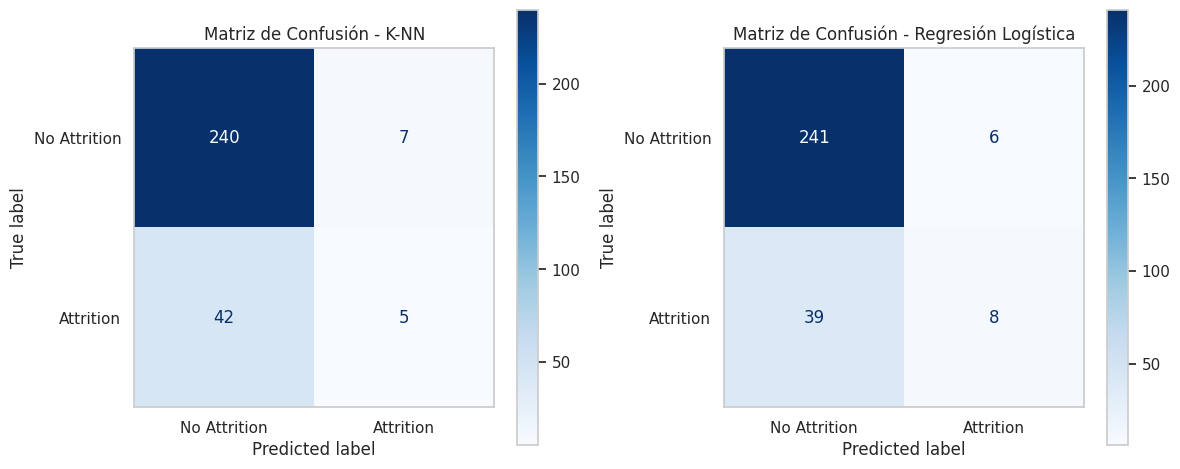

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==========================================
# 4. MODELOS: K-NN Y REGRESIÓN LOGÍSTICA
# ==========================================
models = {
    'K-NN': KNeighborsClassifier(n_neighbors=5),
    'Regresión Logística': LogisticRegression(random_state=42, max_iter=1000)
}

results = []

# Entrenamiento y Predicción
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Calcular métricas requeridas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    results.append({
        'Modelo': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })

# ==========================================
# 5. COMPARACIÓN Y EVALUACIÓN
# ==========================================
df_results = pd.DataFrame(results)

print("\n" * 2)
print("=== TABLA COMPARATIVA DE MODELOS ===")
print("\n" * 1)
display(df_results)
print("\n" * 2)
# Matriz de confusión para ambos modelos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Attrition', 'Attrition'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'Matriz de Confusión - {name}')
    axes[i].grid(False)

plt.tight_layout()
plt.show()
print("\n" * 2)

La variable Attrition está desbalanceada: hay bastantes más empleados que permanecen que empleados que abandonan. Por eso no conviene evaluar ambos modelos únicamente mediante Accuracy.

---

## **CONCLUSIONES:**

# El modelo más eficiente y con el mejor rendimiento global es la **Regresión Logística.**

Según la matriz de confusión de la Regresión Logistica
hay que mirar la columna Predicted label = Attrition:
6 + 8 = 14 empleados.

Es decir, la Regresión Logística predijo que 14 empleados estaban en riesgo de abandonar la empresa.

De esos 14:
8 realmente abandonaron → verdaderos positivos.
6 no abandonaron → falsos positivos.

Por otro lado, había 47 empleados que realmente abandonaron (39 + 8), pero el modelo solamente detectó 8 de ellos.

Por eso el Recall de Attrition es bajo: 8 / 47 ≈ 17,0 %.

---

### Mayor capacidad de detección de renuncian/deserción (Recall):

En un problema de Attrition (deserción laboral), la clase de interés principal es identificar a los empleados en riesgo de renuncia.

La Regresión Logística logró un Recall del 17.02% (detectó 8 casos reales de deserción), superando al 10.64% de K-NN (que solo detectó 5 casos).

**Aclaración:** ambos modelos presentan un Recall muy bajo (17%) debido al fuerte desbalance de clases en la variable objetivo (hay muchas más personas que se quedan en la empresa que las que se van: 247 vs 47).

### Menos falsos positivos y mayor confiabilidad (Precision):

La Regresión Logística obtuvo una Precision del 57.14% frente al 41.67% de K-NN.
Esto significa que cuando la Regresión Logística predice que un empleado se va a ir, acierta en más del 57% de los casos, cometiendo solo 6 falsos positivos (frente a 7 de K-NN), según la matriz de confusión.

### Mejor balance global (F1-Score y ROC-AUC):F1-Score:

La Regresión Logística alcanza 0.2623 comparado con 0.1695 de K-NN.
F1-score es especialmente útil porque combina Precision y Recall en una sola métrica, es decir que busca un equilibrio entre ambas.

### ROC-AUC:

La Regresión Logística presenta 0.7087 frente a 0.6228 de K-NN, demostrando una capacidad significativamente mayor para separar las dos clases (Attrition vs No Attrition).

---




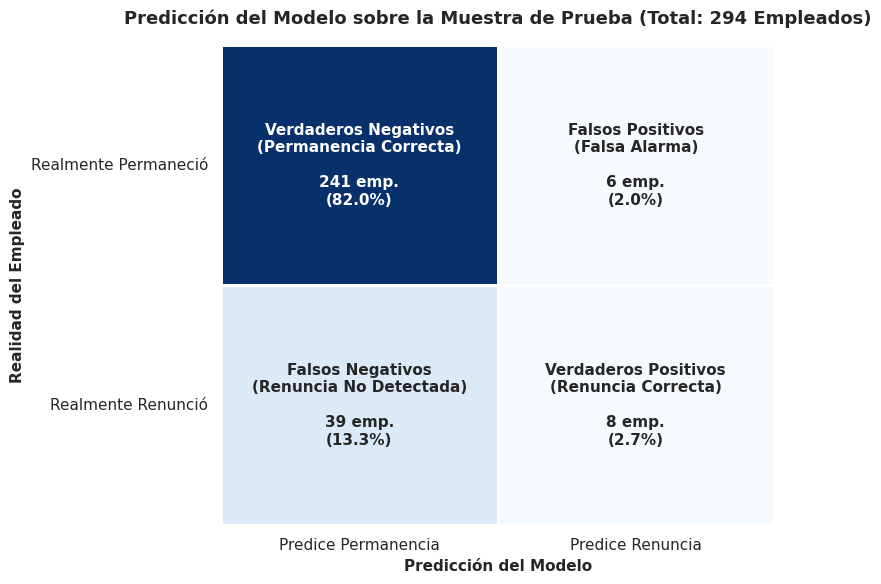

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Obtener las predicciones del modelo de Regresión Logística ya entrenado en el notebook (guardado como 'model')
y_pred_logreg = model.predict(X_test)

# Obtener matriz de confusión (y_test contiene las 294 etiquetas reales)
cm = confusion_matrix(y_test, y_pred_logreg)

# 2. Configurar el gráfico
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Nombres de las categorías
group_names = [
    "Verdaderos Negativos\n(Permanencia Correcta)",
    "Falsos Positivos\n(Falsa Alarma)",
    "Falsos Negativos\n(Renuncia No Detectada)",
    "Verdaderos Positivos\n(Renuncia Correcta)",
]

# Conteos y Porcentajes sobre los 294 empleados
group_counts = [f"{value}" for value in cm.flatten()]
group_percentages = [
    f"{value / np.sum(cm):.1%}" for value in cm.flatten()
]

# Formatear etiquetas internas del mapa de calor
labels = [
    f"{v1}\n\n{v2} emp.\n({v3})"
    for v1, v2, v3 in zip(group_names, group_counts, group_percentages)
]
labels = np.asarray(labels).reshape(2, 2)

# 3. Dibujar Heatmap de la Matriz de Confusión
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    linewidths=2,
    linecolor="white",
    annot_kws={"size": 11, "weight": "bold"},
)

# Títulos y ejes
plt.title(
    f"Predicción del Modelo sobre la Muestra de Prueba (Total: {np.sum(cm)} Empleados)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Predicción del Modelo", fontsize=11, fontweight="bold")
plt.ylabel("Realidad del Empleado", fontsize=11, fontweight="bold")
plt.xticks(
    ticks=[0.5, 1.5], labels=["Predice Permanencia", "Predice Renuncia"]
)
plt.yticks(
    ticks=[0.5, 1.5],
    labels=["Realmente Permaneció", "Realmente Renunció"],
    rotation=0,
)

plt.tight_layout()
plt.show()

# **MEJORAR LA EFICIENCIA EN EL MODELO DE REGRESIÓN LOGISTICA**

### **PRUEBA DE MEJORA DEL RESULTADO DE LA REGRESIÓN LOGISTICA BAJANDO EL UMBRAL A 0.25**

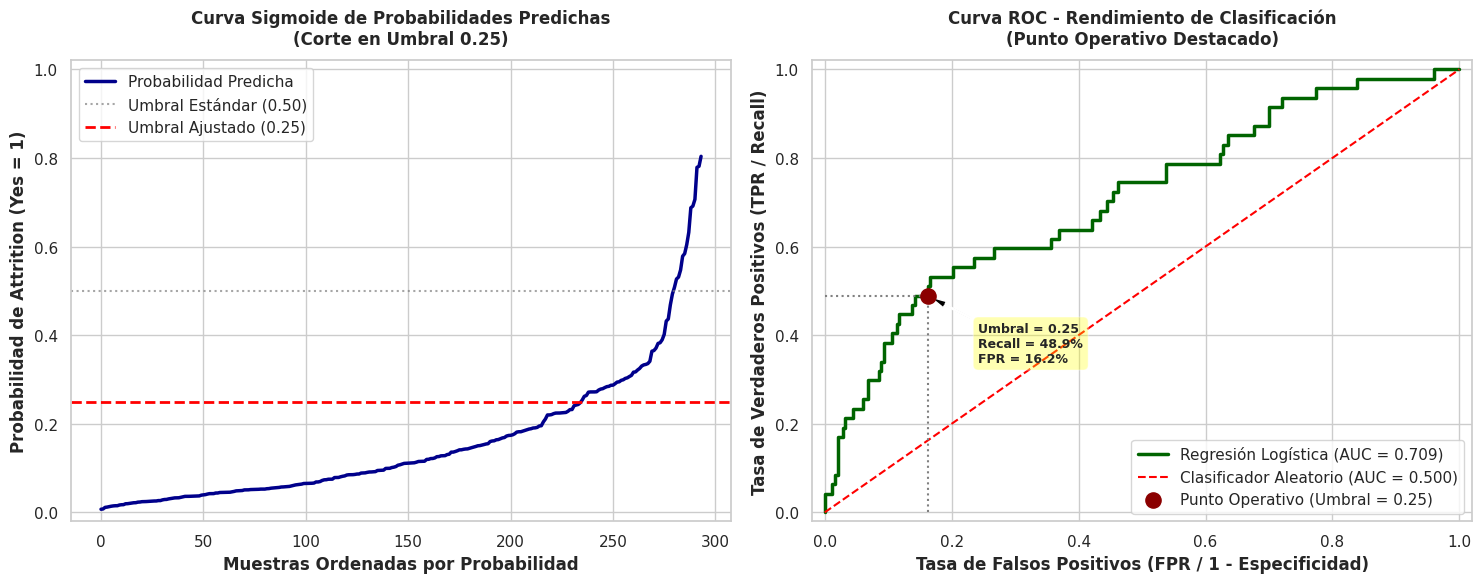

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import auc, roc_curve

# ==========================================
# 1. CÁLCULO DE PROBABILIDADES Y ROC
# ==========================================
UMBRAL = 0.25

# Probabilidades de la clase positiva (Attrition = 1)
y_probs = model.predict_proba(X_test)[:, 1]

# Cálculo de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Identificar coordenadas en ROC para el umbral = 0.25
idx_umbral = np.argmin(np.abs(thresholds - UMBRAL))
fpr_opt = fpr[idx_umbral]
tpr_opt = tpr[idx_umbral]

# Configuración del lienzo (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")

# ==========================================
# SUBPLOT 1: CURVA SIGMOIDE (PROBABILIDADES)
# ==========================================
probs_ordenadas = np.sort(y_probs)

axes[0].plot(
    probs_ordenadas, color="darkblue", lw=2.5, label="Probabilidad Predicha"
)
axes[0].axhline(
    0.50, color="gray", linestyle=":", alpha=0.7, label="Umbral Estándar (0.50)"
)
axes[0].axhline(
    UMBRAL,
    color="red",
    linestyle="--",
    lw=2,
    label=f"Umbral Ajustado ({UMBRAL})",
)

axes[0].set_title(
    f"Curva Sigmoide de Probabilidades Predichas\n(Corte en Umbral {UMBRAL})",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
axes[0].set_xlabel("Muestras Ordenadas por Probabilidad", fontweight="bold")
axes[0].set_ylabel("Probabilidad de Attrition (Yes = 1)", fontweight="bold")
axes[0].legend(loc="upper left")
axes[0].set_ylim([-0.02, 1.02])

# ==========================================
# SUBPLOT 2: CURVA ROC
# ==========================================
axes[1].plot(
    fpr,
    tpr,
    color="darkgreen",
    lw=2.5,
    label=f"Regresión Logística (AUC = {roc_auc:.3f})",
)
axes[1].plot(
    [0, 1],
    [0, 1],
    color="red",
    lw=1.5,
    linestyle="--",
    label="Clasificador Aleatorio (AUC = 0.500)",
)

# Punto operativo destacado en umbral 0.25
axes[1].scatter(
    fpr_opt,
    tpr_opt,
    color="darkred",
    s=120,
    zorder=5,
    label=f"Punto Operativo (Umbral = {UMBRAL})",
)
axes[1].vlines(
    x=fpr_opt, ymin=0, ymax=tpr_opt, colors="gray", linestyles=":", lw=1.5
)
axes[1].hlines(
    y=tpr_opt, xmin=0, xmax=fpr_opt, colors="gray", linestyles=":", lw=1.5
)

# Anotación explicativa
axes[1].annotate(
    f"Umbral = {UMBRAL}\nRecall = {tpr_opt:.1%}\nFPR = {fpr_opt:.1%}",
    xy=(fpr_opt, tpr_opt),
    xytext=(fpr_opt + 0.08, tpr_opt - 0.15),
    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=5),
    fontsize=9,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", fc="yellow", alpha=0.3),
)

axes[1].set_title(
    "Curva ROC - Rendimiento de Clasificación\n(Punto Operativo Destacado)",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
axes[1].set_xlabel(
    "Tasa de Falsos Positivos (FPR / 1 - Especificidad)", fontweight="bold"
)
axes[1].set_ylabel(
    "Tasa de Verdaderos Positivos (TPR / Recall)", fontweight="bold"
)
axes[1].legend(loc="lower right")
axes[1].set_xlim([-0.02, 1.02])
axes[1].set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.show()

### En el gráfico de la curva sigmoide de probabilidades predichas, gracias a este ajuste en el umbral a 0.25, el modelo multiplicó por casi 2.9 veces su capacidad para identificar a los empleados que realmente iban a renunciar.

### El cambio de umbral de decisión de 0.50 a 0.25 no altera la forma de la curva ROC ni su área bajo la curva (AUC), pero desplaza el punto de operación sobre la curva hacia una zona mucho más eficiente para la gestión de retención de personal.

### **COMPARACIÓN ENTRE MODELOS KNN Y REGRESIÓN LOGISTICA**




=== TABLA COMPARATIVA DE MODELOS ===




,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,K-NN (Umbral 0.50),0.8333,0.4167,0.1064,0.1695,0.6228
1,Regresión Logística (Umbral 0.25),0.7959,0.3898,0.4894,0.4340,0.7087


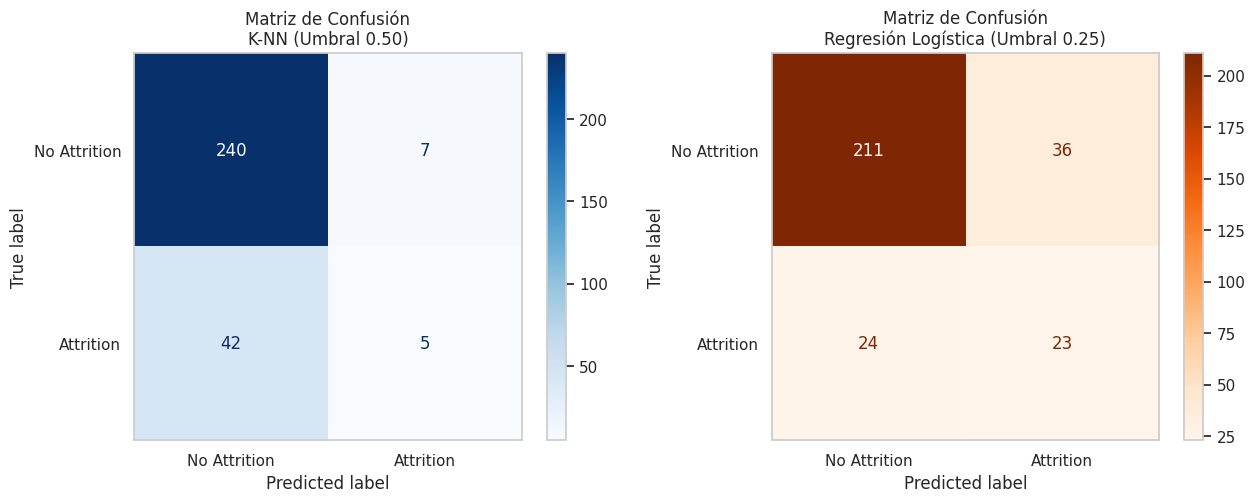

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.neighbors import KNeighborsClassifier

# ==========================================
# DEFINICIÓN DE UMBRAL PERSONALIZADO
# ==========================================
UMBRAL_LOGREG = 0.25  # Umbral optimizado para mejorar el Recall

# Instanciar modelos
knn = KNeighborsClassifier(n_neighbors=5)
logreg = LogisticRegression(random_state=42, max_iter=1000)

# Entrenar modelos
knn.fit(X_train, y_train)
logreg.fit(X_train, y_train)

# Dictionary para iterar
models = {
    'K-NN (Umbral 0.50)': knn,
    f'Regresión Logística (Umbral {UMBRAL_LOGREG})': logreg,
}

results = []
dict_preds = {}

# ==========================================
# EVALUACIÓN Y PREDICCIÓN
# ==========================================
for name, model in models.items():
    # Obtener probabilidades de la clase positiva (Attrition = 1)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Aplicar umbral según el modelo
    if 'Regresión Logística' in name:
        y_pred = (y_proba >= UMBRAL_LOGREG).astype(int)
    else:
        y_pred = model.predict(X_test)  # Usa el umbral por defecto (0.50)

    # Guardar predicciones para las matrices de confusión
    dict_preds[name] = y_pred

    # Calcular métricas requeridas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        'Modelo': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4),
    })

# ==========================================
# COMPARACIÓN Y MOSTRADO DE RESULTADOS
# ==========================================
df_results = pd.DataFrame(results)

print('\n' * 2)
print('=== TABLA COMPARATIVA DE MODELOS ===')
print('\n' * 1)
display(df_results)
print('\n' * 2)

# Visualización de Matrices de Confusión
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, (name, y_pred) in enumerate(dict_preds.items()):
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=['No Attrition', 'Attrition']
    )
    disp.plot(
        ax=axes[i],
        cmap='Blues' if 'K-NN' in name else 'Oranges',
        values_format='d',
    )
    axes[i].set_title(f'Matriz de Confusión\n{name}')
    axes[i].grid(False)

plt.tight_layout()
plt.show()

### **ANALISIS DE LA NUEVA MATRIZ DE CONFUSIÓN CON UMBRAL DE 0.25**

Verdaderos Negativos: 211 (Empleados que permanecieron y el modelo clasificó correctamente como "No Attrition")

Falsos Positivos: 36 (Empleados que permanecieron, pero el modelo los marcó erróneamente como "Attrition" - Falsas Alarmas)

Falsos Negativos: 24 (Empleados que realmente renunciaron, pero el modelo los clasificó como "No Attrition" - Renuncias No Detectadas)

Verdaderos Positivos: 23 (Empleados que realmente renunciaron y el modelo los detectó correctamente como "Attrition")

### **Cumplimiento del Objetivo Estratégico:**

Al bajar el umbral a $0.25$, el modelo pasó de detectar únicamente 8 de 47 renuncias a capturar 23 de 47 renuncias reales, llevando el Recall del $17.0\%$ al $48.9\%$.



### **MATRIZ DE CONFUSIÓN CON NUEVO UMBRAL DE 0.25 EN DETALLE**

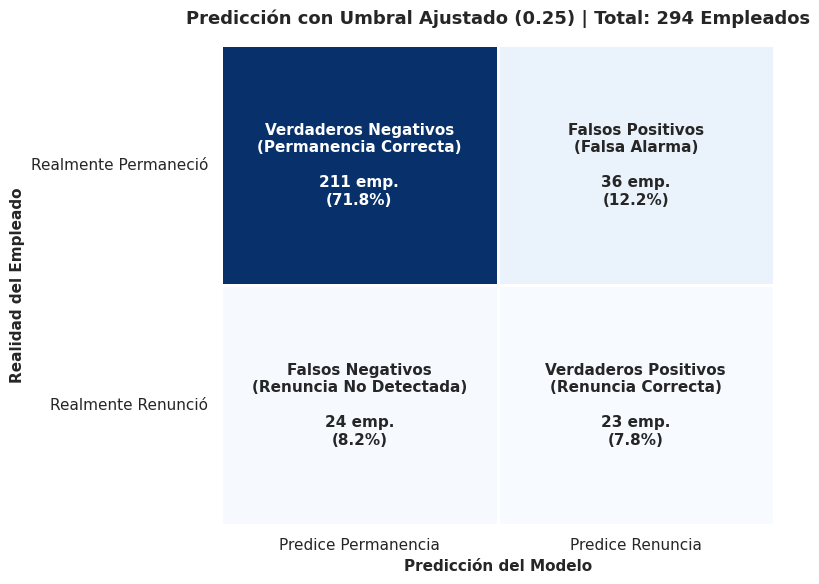

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# 1. GENERAR PREDICCIONES CON EL NUEVO UMBRAL
# ==========================================
UMBRAL = 0.25  # Umbral personalizado para optimizar el Recall

# Obtener las probabilidades predichas para la clase positiva (Attrition = 1)
y_probs_logreg = model.predict_proba(X_test)[:, 1]

# Aplicar la condición según el nuevo umbral
y_pred_logreg_umbral = (y_probs_logreg >= UMBRAL).astype(int)

# Calcular la matriz de confusión ajustada
cm = confusion_matrix(y_test, y_pred_logreg_umbral)

# ==========================================
# 2. CONFIGURACIÓN DEL GRÁFICO
# ==========================================
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

group_names = [
    "Verdaderos Negativos\n(Permanencia Correcta)",
    "Falsos Positivos\n(Falsa Alarma)",
    "Falsos Negativos\n(Renuncia No Detectada)",
    "Verdaderos Positivos\n(Renuncia Correcta)",
]

# Conteos y Porcentajes actualizados sobre el total de la muestra
total_muestras = np.sum(cm)
group_counts = [f"{value}" for value in cm.flatten()]
group_percentages = [f"{value / total_muestras:.1%}" for value in cm.flatten()]

# Formatear etiquetas internas del mapa de calor
labels = [
    f"{v1}\n\n{v2} emp.\n({v3})"
    for v1, v2, v3 in zip(group_names, group_counts, group_percentages)
]
labels = np.asarray(labels).reshape(2, 2)

# ==========================================
# 3. DIBUJAR HEATMAP CON EL NUEVO UMBRAL
# ==========================================
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    linewidths=2,
    linecolor="white",
    annot_kws={"size": 11, "weight": "bold"},
)

# Títulos y ejes dinámicos
plt.title(
    f"Predicción con Umbral Ajustado ({UMBRAL}) | Total: {total_muestras} Empleados",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Predicción del Modelo", fontsize=11, fontweight="bold")
plt.ylabel("Realidad del Empleado", fontsize=11, fontweight="bold")
plt.xticks(
    ticks=[0.5, 1.5], labels=["Predice Permanencia", "Predice Renuncia"]
)
plt.yticks(
    ticks=[0.5, 1.5],
    labels=["Realmente Permaneció", "Realmente Renunció"],
    rotation=0,
)

plt.tight_layout()
plt.show()

# **¿Es mejor 0.25? balanceando la Precisión contra la Sensibilidad (Recall)**

## Definitivamente sí; el objetivo es reducir la fuga de talento activa y la empresa tiene capacidad para realizar intervenciones preventivas con 59 empleados en total

## (23 reales + 36 falsas alarmas)


# **Conclusión Estratégica**

## Aunque el ajuste del umbral a 0.25 incrementó los Falsos Positivos (de 6 a 36 falsas alarmas) y redujo ligeramente la exactitud general en 5.1%, la ganancia operativa es ampliamente superior:

## Se logran salvar y retener 15 talentos clave adicionales que antes abandonaban la empresa sin ser detectados.

## El costo de enviar ofertas o entrevistas preventivas a 36 empleados adicionales es marginal en comparación con el costo económico de reemplazar a 15 profesionales experimentados.